# Análise Exploratória Completa — Estações Meteorológicas e Alagamentos em SP
## TCC · Henrique Nascimento Santos

**Objetivo desta fase:** consolidar uma visão exploratória de todas as fontes de dados de
estações coletadas até agora (CEMADEN local + INMET regional + ERA5/Open-Meteo), entender
sua distribuição espacial em relação ao município de São Paulo, e abrir a investigação
inicial sobre uma hipótese específica: **estações distantes da capital podem ajudar a
prever alagamento com 1 dia de antecedência (D+1)?**

Este notebook é deliberadamente **exploratório, não preditivo** — a modelagem formal
(seleção de modelo, tuning, validação robusta) já está em andamento em outro notebook.
Aqui o foco é: qualidade dos dados, visão espacial, e uma primeira leitura de correlação
defasada (lag) entre estações distantes e o evento de alagamento.

**Fontes utilizadas:**
- `cemaden_estacoes.csv` / `cemaden_sp_diario.csv` — 95 pluviômetros dentro do município de SP
- `stations_metadata.csv` / `consolidated_dataset.csv` — 14 estações INMET (estado de SP, IDW)
- `open_meteo_sp.csv` — reanálise ERA5 para o centro de SP (ponto único)
- `final_data.csv` — registros de alagamento do CGE (target)
- `distritos-sp.geojson` — polígonos dos 96 distritos do município, para referência espacial


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Polygon as MplPolygon, Circle
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from math import radians, cos, sin, asin, sqrt

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9", "axes.grid": True,
    "grid.alpha": 0.35, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, RED, GREEN, ORANGE, PURPLE, GRAY = "#378ADD", "#E05252", "#1D9E75", "#EF9F27", "#8B5CF6", "#8A8A8A"

SP_LAT, SP_LON = -23.5505, -46.6333

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*asin(sqrt(a))

print("✓ Setup concluído.")


✓ Setup concluído.


## 1. Carregamento de Todas as Fontes

In [2]:
BASE = "../../data/outputs/datasets"

# ── CEMADEN ───────────────────────────────────────────────────────────────
cemaden_estacoes = pd.read_csv(f"{BASE}/cemaden_estacoes.csv")
cemaden_diario    = pd.read_csv(f"{BASE}/cemaden_sp_diario.csv", parse_dates=["date"])

# ── INMET ─────────────────────────────────────────────────────────────────
inmet_estacoes = pd.read_csv(f"{BASE}/stations_metadata.csv")
inmet_diario    = pd.read_csv(f"{BASE}/consolidated_dataset.csv", parse_dates=["date"])

# ── ERA5 / Open-Meteo ─────────────────────────────────────────────────────
era5 = pd.read_csv(f"{BASE}/open_meteo_sp.csv", parse_dates=["date"])

# ── Alagamentos (CGE) ─────────────────────────────────────────────────────
alag_raw = pd.read_csv(f"{BASE}/final_data.csv")
alag_raw["date"] = pd.to_datetime(alag_raw["date"], format="%d-%m-%Y", errors="coerce")
alag_daily = (
    alag_raw.groupby("date")
    .agg(n_events=("current_zone","count"),
         n_intransit=("status", lambda x: (x=="Inativo Intransitável").sum()),
         has_flooding=("current_zone", lambda x: int(x.notna().any())))
    .reset_index()
)
all_days = pd.DataFrame({"date": pd.date_range("2015-01-01","2026-05-31")})
alag_daily = pd.merge(all_days, alag_daily, on="date", how="left")
alag_daily["has_flooding"] = alag_daily["has_flooding"].fillna(0).astype(int)
alag_daily[["n_events","n_intransit"]] = alag_daily[["n_events","n_intransit"]].fillna(0)

# ── Distritos (geojson) ───────────────────────────────────────────────────
with open("../mapa/distritos-sp.geojson", encoding="utf-8") as f:
    geojson_distritos = json.load(f)

print("✓ Todas as fontes carregadas:")
print(f"  CEMADEN  : {len(cemaden_estacoes)} estações | {len(cemaden_diario)} dias")
print(f"  INMET    : {len(inmet_estacoes)} estações | {len(inmet_diario)} dias")
print(f"  ERA5     : {len(era5)} dias")
print(f"  CGE      : {len(alag_daily)} dias | {alag_daily['has_flooding'].sum()} com alagamento")
print(f"  Distritos: {len(geojson_distritos['features'])} polígonos")


✓ Todas as fontes carregadas:
  CEMADEN  : 95 estações | 4166 dias
  INMET    : 14 estações | 4169 dias
  ERA5     : 4169 dias
  CGE      : 4169 dias | 1031 com alagamento
  Distritos: 96 polígonos


## 2. Qualidade e Cobertura dos Dados por Fonte

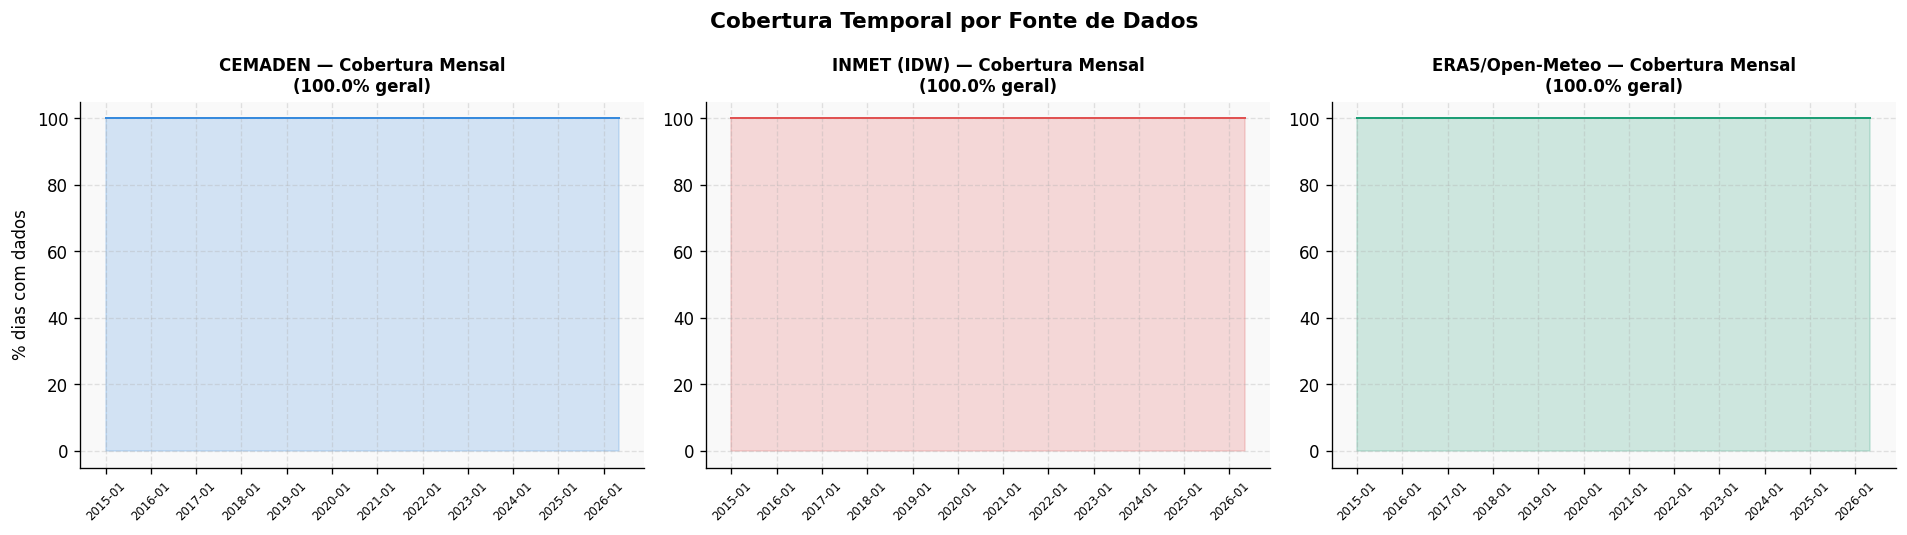

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 2.1 Cobertura temporal CEMADEN
ax = axes[0]
cemaden_diario["month_period"] = cemaden_diario["date"].dt.to_period("M")
cov_cem = cemaden_diario.groupby("month_period")["cemaden_precip_idw_mm"].apply(lambda x: x.notna().mean()*100)
ax.plot(cov_cem.index.astype(str), cov_cem.values, color=BLUE, linewidth=1.2)
ax.fill_between(range(len(cov_cem)), cov_cem.values, alpha=0.2, color=BLUE)
ax.set_title(f"CEMADEN — Cobertura Mensal\n({cemaden_diario['cemaden_precip_idw_mm'].notna().mean()*100:.1f}% geral)", fontweight="bold", fontsize=10)
ax.set_ylabel("% dias com dados")
tick_idx = range(0, len(cov_cem), 12)
ax.set_xticks(list(tick_idx))
ax.set_xticklabels([str(cov_cem.index[i]) for i in tick_idx], rotation=45, fontsize=7)

# 2.2 Cobertura temporal INMET (IDW)
ax = axes[1]
inmet_diario["month_period"] = inmet_diario["date"].dt.to_period("M")
cov_inmet = inmet_diario.groupby("month_period")["sp_precip_mm"].apply(lambda x: x.notna().mean()*100)
ax.plot(cov_inmet.index.astype(str), cov_inmet.values, color=RED, linewidth=1.2)
ax.fill_between(range(len(cov_inmet)), cov_inmet.values, alpha=0.2, color=RED)
ax.set_title(f"INMET (IDW) — Cobertura Mensal\n({inmet_diario['sp_precip_mm'].notna().mean()*100:.1f}% geral)", fontweight="bold", fontsize=10)
tick_idx = range(0, len(cov_inmet), 12)
ax.set_xticks(list(tick_idx))
ax.set_xticklabels([str(cov_inmet.index[i]) for i in tick_idx], rotation=45, fontsize=7)

# 2.3 Cobertura ERA5
ax = axes[2]
era5["month_period"] = era5["date"].dt.to_period("M")
cov_era5 = era5.groupby("month_period")["precipitation_sum"].apply(lambda x: x.notna().mean()*100)
ax.plot(cov_era5.index.astype(str), cov_era5.values, color=GREEN, linewidth=1.2)
ax.fill_between(range(len(cov_era5)), cov_era5.values, alpha=0.2, color=GREEN)
ax.set_title(f"ERA5/Open-Meteo — Cobertura Mensal\n({era5['precipitation_sum'].notna().mean()*100:.1f}% geral)", fontweight="bold", fontsize=10)
tick_idx = range(0, len(cov_era5), 12)
ax.set_xticks(list(tick_idx))
ax.set_xticklabels([str(cov_era5.index[i]) for i in tick_idx], rotation=45, fontsize=7)

plt.suptitle("Cobertura Temporal por Fonte de Dados", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Mapa Geoespacial — CEMADEN + INMET sobre o Município de SP

Este é o mapa central desta análise: sobrepõe as estações **CEMADEN** (dentro do
município) e **INMET** (estado de SP, mais distantes) ao polígono dos distritos de São
Paulo, com círculos de referência de distância para dar noção de escala.


In [4]:
def extrair_poligonos(geojson):
    resultado = []
    for feature in geojson["features"]:
        nome = feature["properties"].get("ds_nome", "")
        geom = feature["geometry"]
        if geom["type"] == "Polygon":
            aneis = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            aneis = geom["coordinates"]
        else:
            continue
        patches_distrito = []
        for polygon in aneis:
            pts = np.array(polygon[0])
            patches_distrito.append(MplPolygon(pts, closed=True))
        resultado.append((patches_distrito, nome))
    return resultado

poligonos = extrair_poligonos(geojson_distritos)
print(f"✓ {len(poligonos)} distritos extraídos do geojson.")


✓ 96 distritos extraídos do geojson.


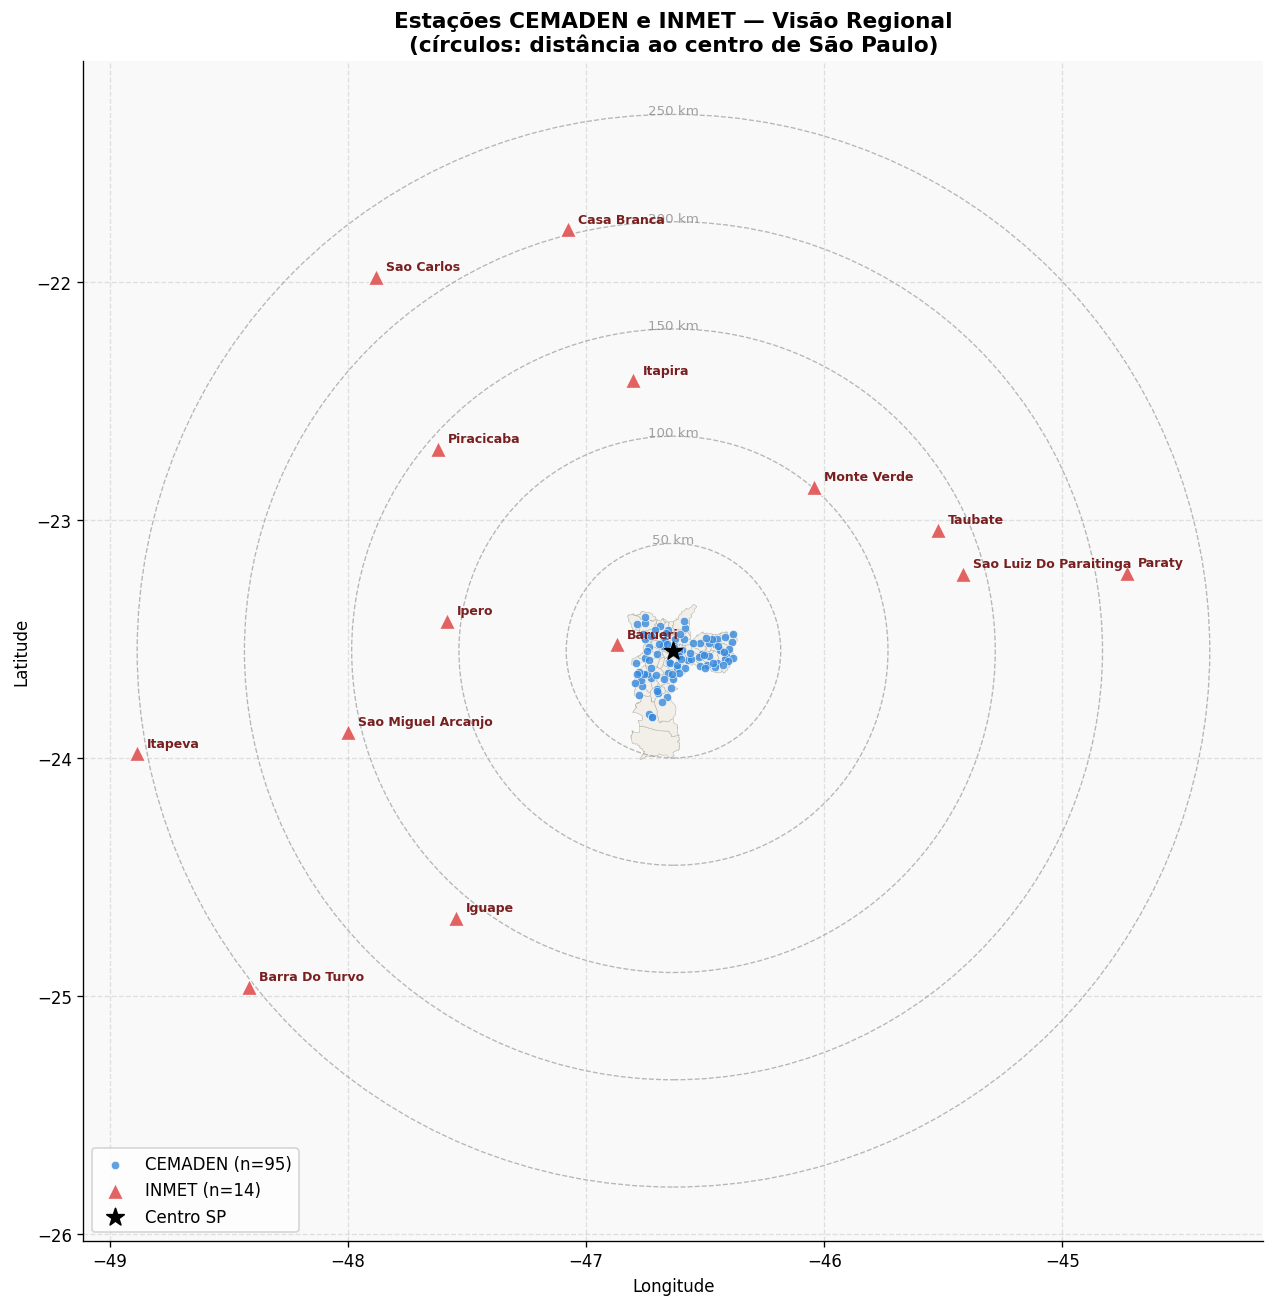


Distância das estações INMET ao centro de SP:
                  nome  dist_sp_km
               BARUERI   24.254590
           MONTE VERDE   97.478306
                 IPERO   98.092258
               TAUBATE  126.923624
               ITAPIRA  127.483240
SAO LUIZ DO PARAITINGA  129.203498
            PIRACICABA  138.306793
    SAO MIGUEL ARCANJO  144.103434
                IGUAPE  155.304395
                PARATY  197.926367
           CASA BRANCA  201.965612
            SAO CARLOS  216.623321
               ITAPEVA  234.192939
        BARRA DO TURVO  239.445650


In [5]:
# ── Mapa de visão regional (estado de SP) — mostra a escala completa ──────
fig, ax = plt.subplots(figsize=(11, 11))

# Distritos de SP (pequenos nessa escala, mas servem de referência central)
all_patches = []
for patches_distrito, _ in poligonos:
    all_patches.extend(patches_distrito)
pc = PatchCollection(all_patches, facecolor="#F1EFE8", edgecolor="#B4B2A9", linewidths=0.3)
ax.add_collection(pc)

# Círculos de distância de referência (50, 100, 150, 200, 250 km)
for raio_km in [50, 100, 150, 200, 250]:
    # Aproximação simples: 1 grau de latitude ≈ 111 km
    raio_graus = raio_km / 111
    circ = Circle((SP_LON, SP_LAT), raio_graus, fill=False,
                  edgecolor=GRAY, linewidth=0.8, linestyle="--", alpha=0.6, zorder=2)
    ax.add_patch(circ)
    ax.annotate(f"{raio_km} km", (SP_LON, SP_LAT + raio_graus),
               fontsize=8, color=GRAY, ha="center", alpha=0.8)

# CEMADEN (dentro de SP)
ax.scatter(cemaden_estacoes["lon"], cemaden_estacoes["lat"], c=BLUE, s=25,
          alpha=0.8, edgecolors="white", linewidths=0.4, zorder=5, label=f"CEMADEN (n={len(cemaden_estacoes)})")

# INMET (estado de SP)
ax.scatter(inmet_estacoes["lon"], inmet_estacoes["lat"], c=RED, s=90,
          alpha=0.9, marker="^", edgecolors="white", linewidths=0.7, zorder=6,
          label=f"INMET (n={len(inmet_estacoes)})")

# Anotar nome das estações INMET (mais espaçadas, vale anotar todas)
for _, row in inmet_estacoes.iterrows():
    ax.annotate(row["nome"].title(), (row["lon"], row["lat"]),
               textcoords="offset points", xytext=(6, 4), fontsize=7.5,
               color="#791F1F", fontweight="bold", zorder=7)

# Centro de SP
ax.scatter([SP_LON], [SP_LAT], c="black", s=120, marker="*", zorder=8, label="Centro SP")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Estações CEMADEN e INMET — Visão Regional\n(círculos: distância ao centro de São Paulo)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower left", fontsize=10, frameon=True, facecolor="white")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print("\nDistância das estações INMET ao centro de SP:")
print(inmet_estacoes[["nome","dist_sp_km"]].sort_values("dist_sp_km").to_string(index=False))


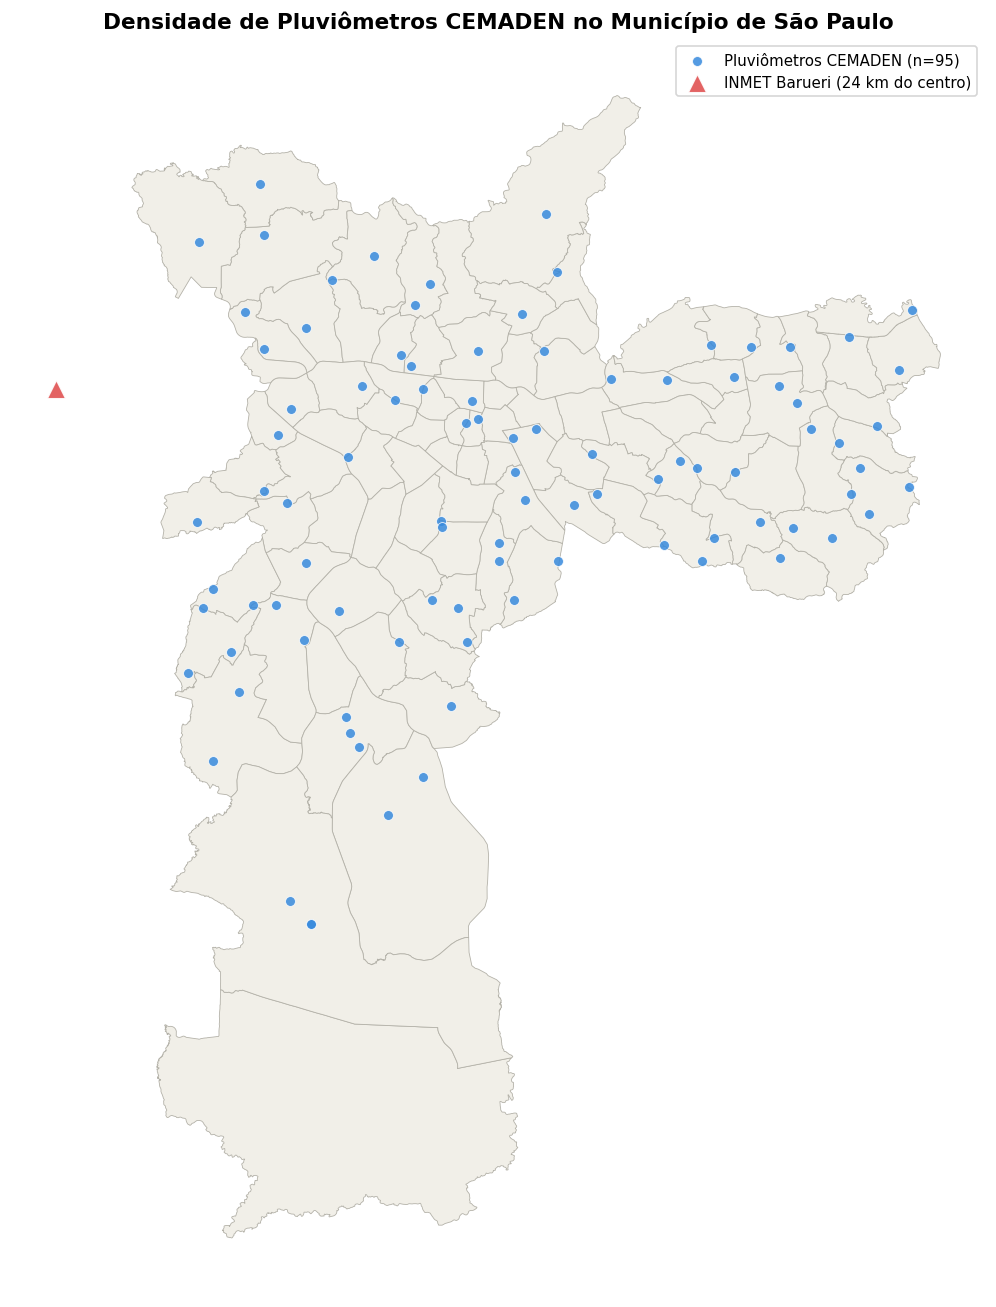

In [6]:
# ── Mapa de zoom — só o município de SP, mostrando densidade do CEMADEN ──
fig, ax = plt.subplots(figsize=(9, 11))

all_patches = []
for patches_distrito, _ in poligonos:
    all_patches.extend(patches_distrito)
pc = PatchCollection(all_patches, facecolor="#F1EFE8", edgecolor="#B4B2A9", linewidths=0.5)
ax.add_collection(pc)
ax.autoscale()

ax.scatter(cemaden_estacoes["lon"], cemaden_estacoes["lat"], c=BLUE, s=35,
          alpha=0.85, edgecolors="white", linewidths=0.5, zorder=5,
          label=f"Pluviômetros CEMADEN (n={len(cemaden_estacoes)})")

# Barueri (única estação INMET próxima) — mostrar se estiver no enquadramento
barueri = inmet_estacoes[inmet_estacoes["nome"].str.contains("BARUERI", case=False)]
if not barueri.empty:
    ax.scatter(barueri["lon"], barueri["lat"], c=RED, s=120, marker="^",
              alpha=0.9, edgecolors="white", linewidths=0.8, zorder=6,
              label=f"INMET Barueri ({barueri['dist_sp_km'].iloc[0]:.0f} km do centro)")

ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Densidade de Pluviômetros CEMADEN no Município de São Paulo",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9, frameon=True, facecolor="white")
plt.tight_layout()
plt.show()


### 3.1 Mapa Combinado — Estações + Locais de Alagamento

Como o objetivo final é prever alagamento, é importante visualizar **onde estão as
estações de medição em relação a onde o fenômeno realmente ocorre**. Este mapa sobrepõe
os pluviômetros CEMADEN aos locais de alagamento por distrito (registros do CGE),
permitindo avaliar visualmente se a rede de monitoramento tem boa cobertura nas regiões
mais críticas da cidade.


In [7]:
import unicodedata
import re
from collections import Counter

def normalizar(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.strip().upper()
    return "".join(c for c in unicodedata.normalize("NFD", texto)
                   if unicodedata.category(c) != "Mn")

# Centroide aproximado de cada distrito (média dos vértices do maior anel)
centroides_distrito = {}
for feature in geojson_distritos["features"]:
    nome = normalizar(feature["properties"].get("ds_nome", ""))
    geom = feature["geometry"]
    aneis = [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
    maior_anel = max((np.array(p[0]) for p in aneis), key=len)
    centroides_distrito[nome] = maior_anel.mean(axis=0)  # [lon, lat]

def encontrar_centroide(bairro_norm):
    """
    Tenta casar o nome do bairro/zona do CGE com um distrito do geojson.
    Alguns valores de 'neighbor' no final_data.csv são, na verdade, nomes
    de SUBPREFEITURA (que agrupam vários distritos), no formato
    'DISTRITO1/ DISTRITO2' ou 'DISTRITO1/DISTRITO2'. Nesses casos, casamos
    pelo primeiro distrito do nome composto que existir no geojson.
    """
    if bairro_norm in centroides_distrito:
        return centroides_distrito[bairro_norm]
    # Tentar dividir por barra (subprefeituras compostas)
    partes = [normalizar(p) for p in re.split(r"[/]", bairro_norm)]
    for parte in partes:
        if parte in centroides_distrito:
            return centroides_distrito[parte]
    # Tentar remover apóstrofo (ex: M'BOI MIRIM -> MBOI MIRIM) e variações comuns
    sem_apostrofo = bairro_norm.replace("'", "")
    if sem_apostrofo in centroides_distrito:
        return centroides_distrito[sem_apostrofo]
    return None

# Contar eventos de alagamento por bairro (nível de distrito) e por zona
contagem_bairro = Counter()
zona_por_bairro = {}
for _, row in alag_raw.iterrows():
    bairro = normalizar(row.get("neighbor", ""))
    zona   = row.get("current_zone", "")
    if bairro:
        contagem_bairro[bairro] += 1
        zona_por_bairro[bairro] = zona

print(f"{len(contagem_bairro)} bairros únicos com eventos registrados.")

# Casar com os centroides do geojson (com fallback para nomes compostos)
pontos_lon, pontos_lat, pontos_n, pontos_zona, pontos_nome = [], [], [], [], []
nao_casados = []
for bairro, n in contagem_bairro.items():
    centroide = encontrar_centroide(bairro)
    if centroide is not None:
        lon, lat = centroide
        pontos_lon.append(lon); pontos_lat.append(lat)
        pontos_n.append(n); pontos_zona.append(zona_por_bairro[bairro])
        pontos_nome.append(bairro)
    else:
        nao_casados.append((bairro, n))

print(f"✓ {len(pontos_lon)} bairros casados com distritos do geojson "
      f"(incluindo correspondência parcial de subprefeituras compostas).")
if nao_casados:
    print(f"[aviso] {len(nao_casados)} bairros ainda não casados (maiores primeiro):")
    for nome, n in sorted(nao_casados, key=lambda x: -x[1])[:8]:
        print(f"    {nome}: {n} eventos")


32 bairros únicos com eventos registrados.
✓ 29 bairros casados com distritos do geojson (incluindo correspondência parcial de subprefeituras compostas).
[aviso] 3 bairros ainda não casados (maiores primeiro):
    M'BOI MIRIM: 161 eventos
    SAO MIGUEL PAULISTA: 108 eventos
    CAPELA DO SOCORRO: 87 eventos


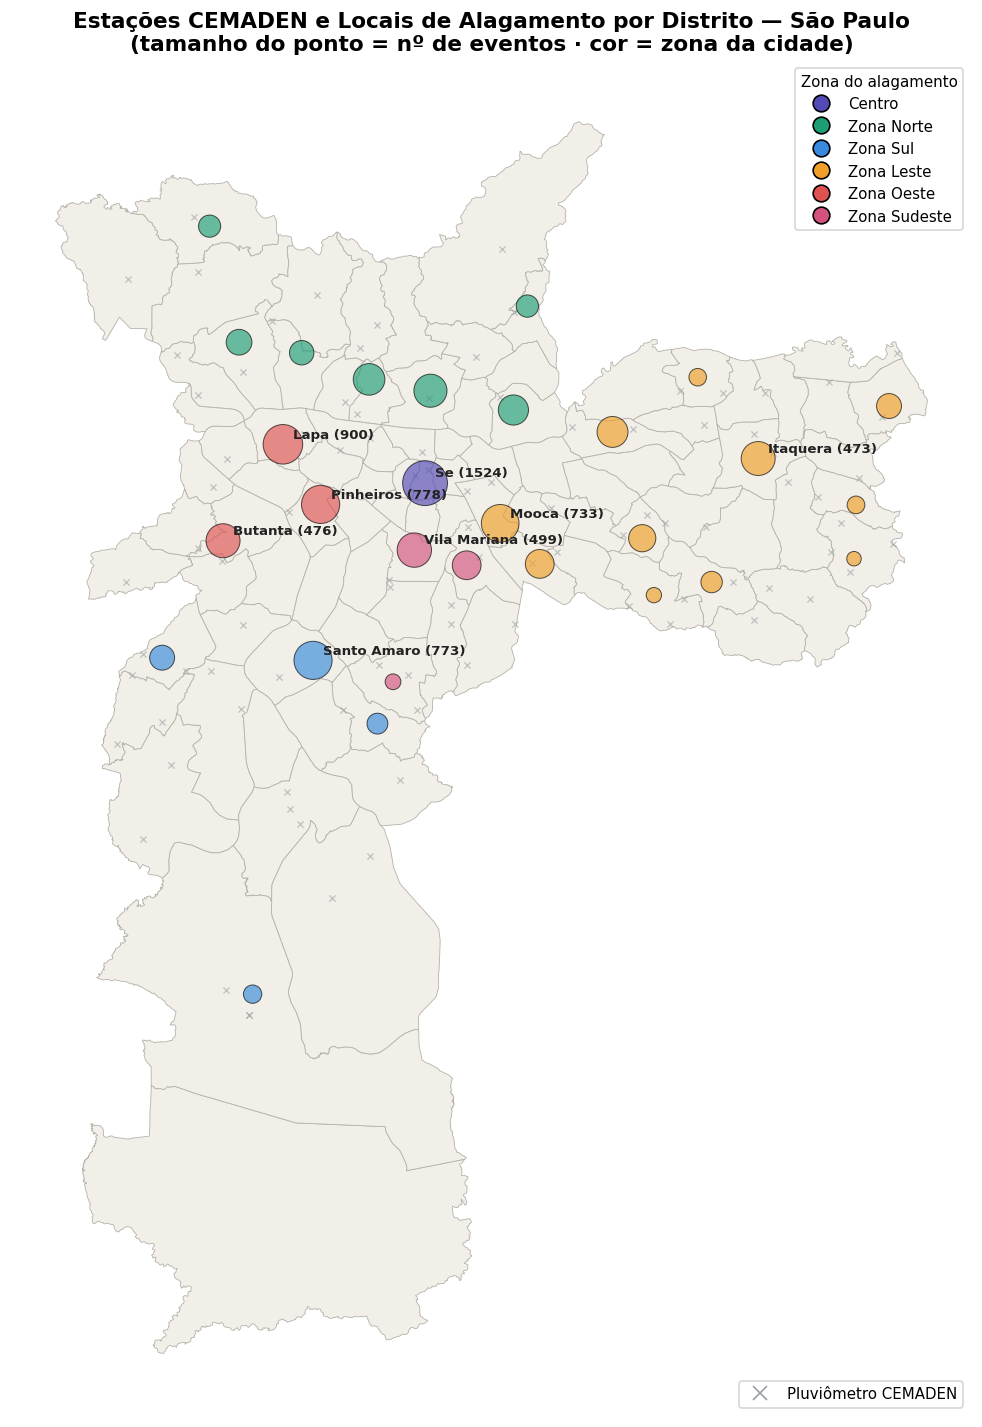

In [8]:
# Paleta por zona — consistente com os gráficos já usados no TCC
ZONA_CORES = {
    "Centro": "#534AB7", "Zona Norte": "#1D9E75", "Zona Sul": "#378ADD",
    "Zona Leste": "#EF9F27", "Zona Oeste": "#E05252", "Zona Sudeste": "#D4537E",
}

fig, ax = plt.subplots(figsize=(10, 12))

all_patches = []
for patches_distrito, _ in poligonos:
    all_patches.extend(patches_distrito)
pc = PatchCollection(all_patches, facecolor="#F1EFE8", edgecolor="#B4B2A9", linewidths=0.5)
ax.add_collection(pc)
ax.autoscale()

# Camada 1: pluviômetros CEMADEN (estações)
ax.scatter(cemaden_estacoes["lon"], cemaden_estacoes["lat"], c="#9AA0A6", s=14,
          alpha=0.55, marker="x", linewidths=0.8, zorder=4, label=f"Pluviômetros CEMADEN (n={len(cemaden_estacoes)})")

# Camada 2: alagamentos por distrito, coloridos por zona, tamanho por nº de eventos
pontos_n_arr = np.array(pontos_n)
tamanhos = 25 + 700 * np.sqrt(pontos_n_arr / pontos_n_arr.max())
cores_pontos = [ZONA_CORES.get(z, "#999999") for z in pontos_zona]

ax.scatter(pontos_lon, pontos_lat, s=tamanhos, c=cores_pontos, alpha=0.65,
          edgecolors="black", linewidths=0.6, zorder=5)

# Anotar os top 8 bairros com mais eventos
top_idx = np.argsort(pontos_n_arr)[::-1][:8]
for i in top_idx:
    ax.annotate(f"{pontos_nome[i].title()} ({pontos_n_arr[i]})",
               (pontos_lon[i], pontos_lat[i]), textcoords="offset points",
               xytext=(6, 4), fontsize=8, fontweight="bold", color="#222222", zorder=6)

# Legendas: zona (cor) + estações (marcador)
legend_zona = [Line2D([0],[0], marker="o", color="w", markerfacecolor=cor,
                      markeredgecolor="black", markersize=10, label=zona)
              for zona, cor in ZONA_CORES.items() if zona in set(pontos_zona)]
legend_estacao = [Line2D([0],[0], marker="x", color="#9AA0A6", markersize=8,
                         linewidth=0, label="Pluviômetro CEMADEN")]

leg1 = ax.legend(handles=legend_zona, loc="upper right", fontsize=9, title="Zona do alagamento",
                 title_fontsize=9, frameon=True, facecolor="white")
ax.add_artist(leg1)
ax.legend(handles=legend_estacao, loc="lower right", fontsize=9, frameon=True, facecolor="white")

ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Estações CEMADEN e Locais de Alagamento por Distrito — São Paulo\n"
             "(tamanho do ponto = nº de eventos · cor = zona da cidade)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Leitura deste mapa:** se os pontos de maior tamanho (mais alagamentos) estiverem
visualmente afastados dos "x" cinza (pluviômetros), isso sinaliza uma região onde a chuva
local pode não estar sendo bem capturada pela rede CEMADEN, o que é relevante tanto para a
qualidade do modelo quanto para uma futura recomendação de expansão da rede de
monitoramento.


## 4. Comparação das Três Fontes de Precipitação

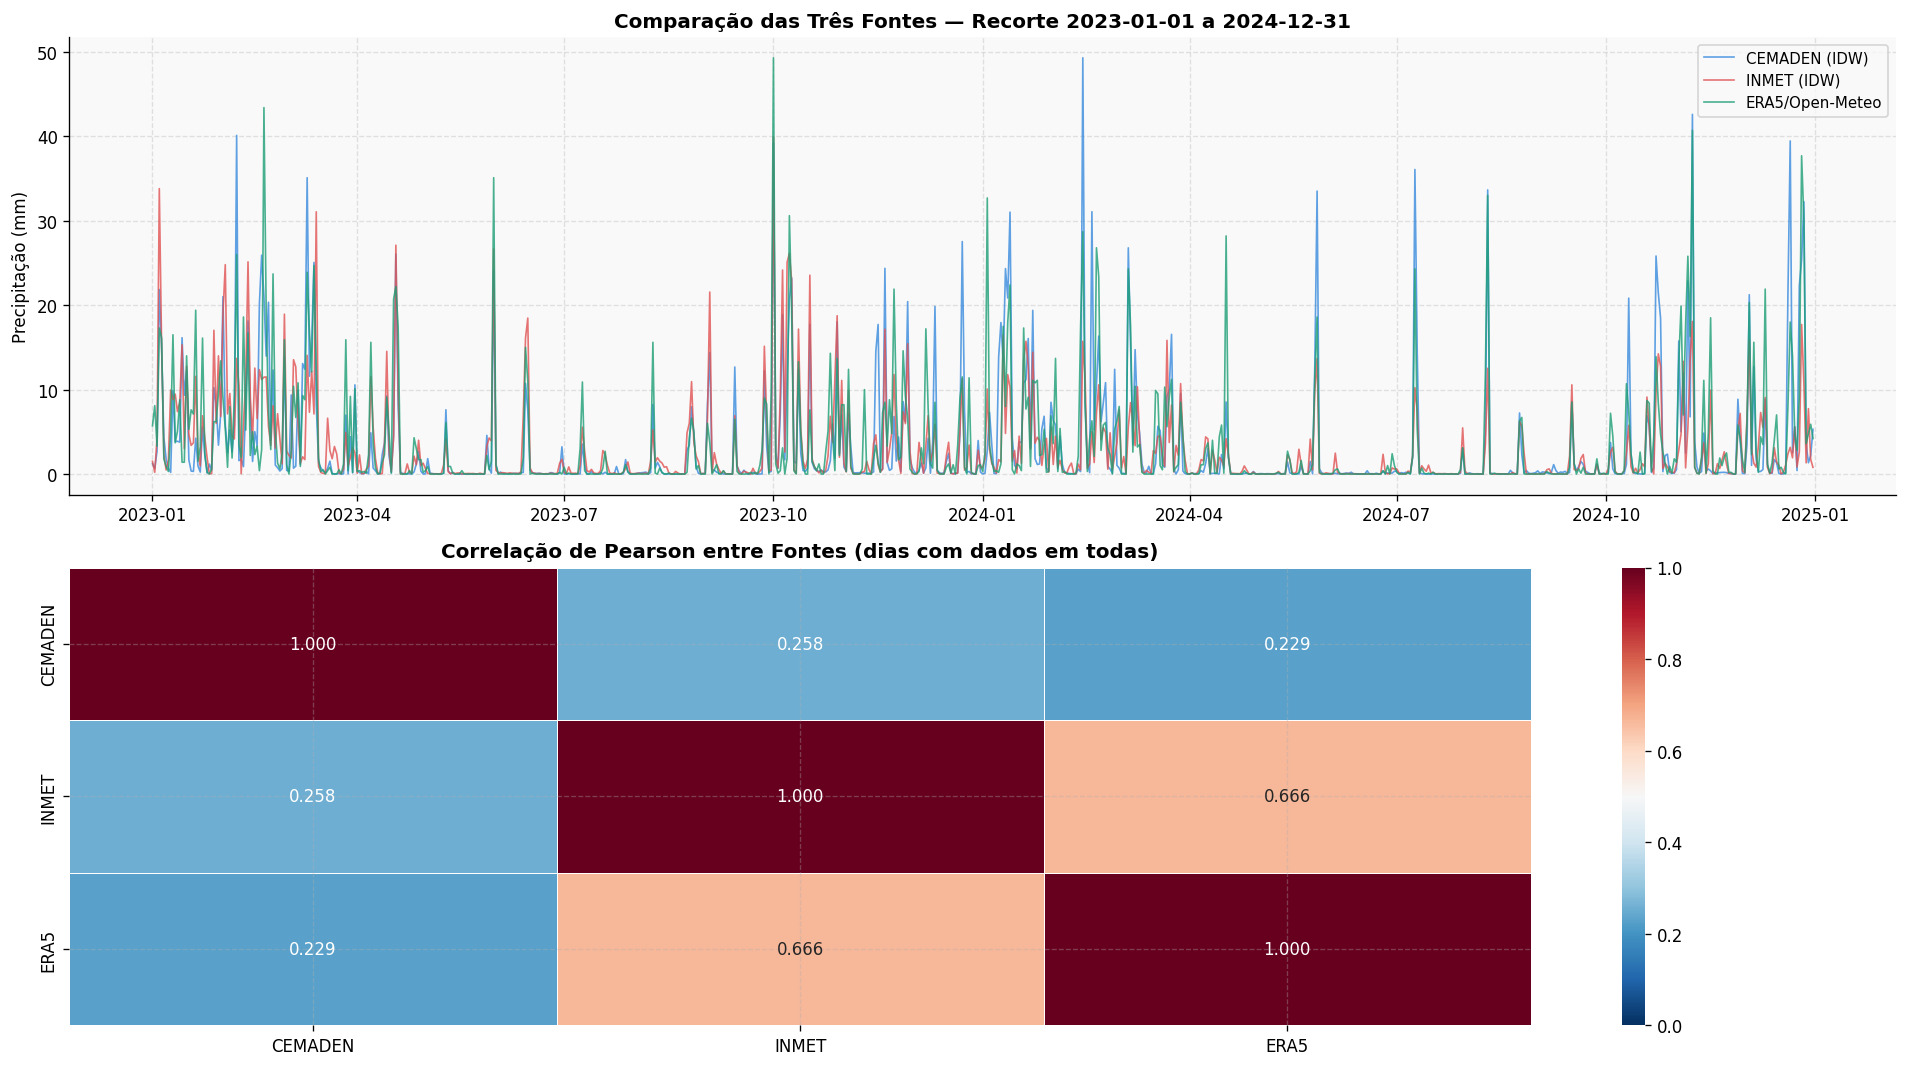

Dias com dados simultâneos nas 3 fontes: 4,166


In [9]:
# Merge das três séries de precipitação no mesmo eixo de tempo
df_compare = (
    cemaden_diario[["date","cemaden_precip_idw_mm","cemaden_precip_median_mm"]]
    .merge(inmet_diario[["date","sp_precip_mm"]], on="date", how="outer")
    .merge(era5[["date","precipitation_sum"]], on="date", how="outer")
    .sort_values("date")
)
df_compare["date"] = pd.to_datetime(df_compare["date"])

# IMPORTANTE: sharex=False (padrão) é obrigatório aqui. O segundo subplot é um
# heatmap com eixo X categórico (nomes das fontes); se compartilhado com o
# primeiro subplot (eixo X de datas), o heatmap sobrescreve a escala do eixo
# X compartilhado e a série temporal do primeiro subplot some visualmente,
# mesmo com os dados corretos plotados (bug já visto e corrigido nesta versão).
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# 4.1 Série completa (zoom em 2 anos para legibilidade)
ax = axes[0]
lim_inicio = pd.Timestamp("2023-01-01")
lim_fim    = pd.Timestamp("2024-12-31")
mask = (df_compare["date"] >= lim_inicio) & (df_compare["date"] <= lim_fim)
sub = df_compare.loc[mask].copy()
if sub.empty:
    sub = df_compare.tail(730).copy()
ax.plot(sub["date"], sub["cemaden_precip_idw_mm"], color=BLUE, linewidth=1, alpha=0.8, label="CEMADEN (IDW)")
ax.plot(sub["date"], sub["sp_precip_mm"], color=RED, linewidth=1, alpha=0.8, label="INMET (IDW)")
ax.plot(sub["date"], sub["precipitation_sum"], color=GREEN, linewidth=1, alpha=0.8, label="ERA5/Open-Meteo")
ax.set_ylabel("Precipitação (mm)")
ax.set_title(f"Comparação das Três Fontes — Recorte {sub['date'].min().date()} a {sub['date'].max().date()}", fontweight="bold")
ax.legend(fontsize=9)

# 4.2 Correlação entre fontes (scatter matrix simplificado)
ax = axes[1]
df_corr = df_compare.dropna(subset=["cemaden_precip_idw_mm","sp_precip_mm","precipitation_sum"])
corr_matrix = df_corr[["cemaden_precip_idw_mm","sp_precip_mm","precipitation_sum"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r", center=0.5,
           vmin=0, vmax=1, ax=ax, linewidths=0.5,
           xticklabels=["CEMADEN","INMET","ERA5"], yticklabels=["CEMADEN","INMET","ERA5"])
ax.set_title("Correlação de Pearson entre Fontes (dias com dados em todas)", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Dias com dados simultâneos nas 3 fontes: {len(df_corr):,}")


## 5. Sazonalidade — Comparação entre Fontes

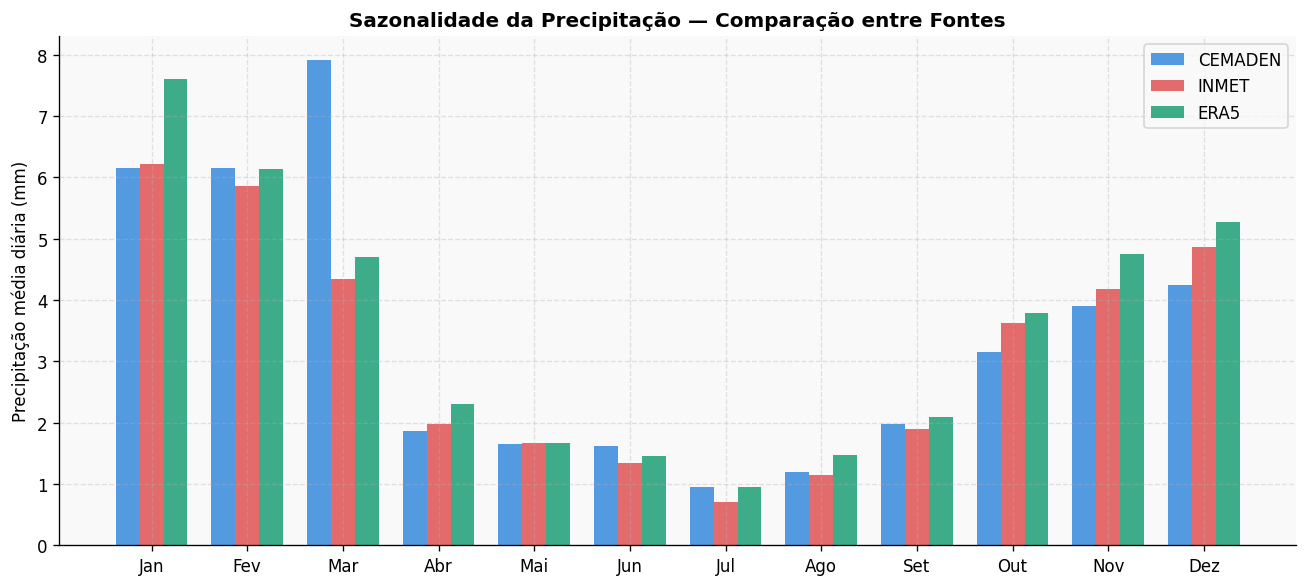

In [10]:
df_compare["month"] = df_compare["date"].dt.month
MONTH_NAMES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

monthly_avg = df_compare.groupby("month")[["cemaden_precip_idw_mm","sp_precip_mm","precipitation_sum"]].mean()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(1, 13)
width = 0.25
ax.bar(x - width, monthly_avg["cemaden_precip_idw_mm"], width, color=BLUE, alpha=0.85, label="CEMADEN")
ax.bar(x,         monthly_avg["sp_precip_mm"],          width, color=RED,  alpha=0.85, label="INMET")
ax.bar(x + width, monthly_avg["precipitation_sum"],     width, color=GREEN,alpha=0.85, label="ERA5")
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Precipitação média diária (mm)")
ax.set_title("Sazonalidade da Precipitação — Comparação entre Fontes", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Visão Geral dos Alagamentos (Target)

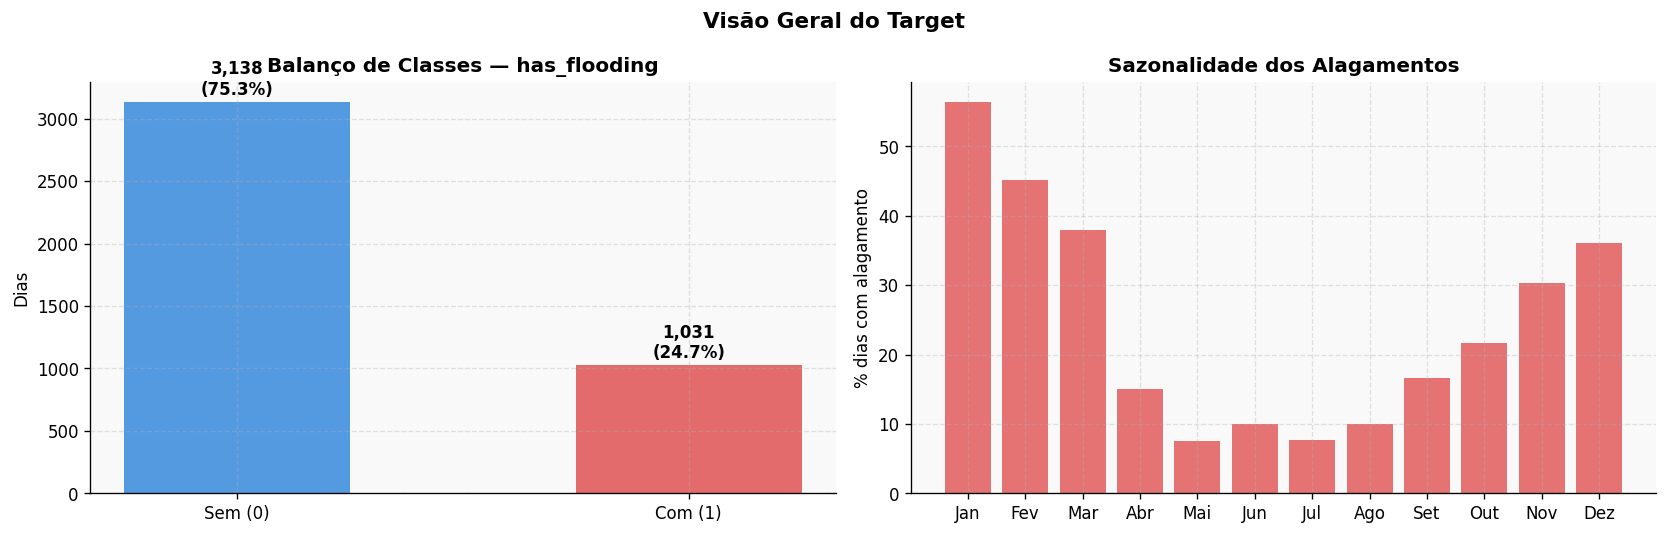

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
counts = alag_daily["has_flooding"].value_counts()
bars = ax.bar(["Sem (0)","Com (1)"], counts.values, color=[BLUE, RED], alpha=0.85, width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+20, f"{v:,}\n({v/len(alag_daily)*100:.1f}%)",
            ha="center", va="bottom", fontweight="bold")
ax.set_title("Balanço de Classes — has_flooding", fontweight="bold")
ax.set_ylabel("Dias")

ax = axes[1]
alag_daily["month"] = alag_daily["date"].dt.month
monthly_flood = alag_daily.groupby("month")["has_flooding"].mean() * 100
ax.bar(range(1,13), monthly_flood.values, color=RED, alpha=0.8)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("% dias com alagamento")
ax.set_title("Sazonalidade dos Alagamentos", fontweight="bold")

plt.suptitle("Visão Geral do Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Investigação Inicial — Estações Distantes Ajudam a Prever D+1?

**Hipótese:** sistemas de chuva (frentes frias, linhas de instabilidade) geralmente se
deslocam sobre o estado de São Paulo em direções preferenciais (tipicamente
sudoeste→nordeste). Se isso for verdade, a chuva registrada **hoje** em estações distantes
do interior poderia conter informação sobre a chuva que **chegará a São Paulo no dia
seguinte** — um sinal de "advecção" que nenhuma estação dentro do município captura
sozinha, pois ela só vê o evento quando ele já chegou.

Esta seção é **exploratória**: testamos a correlação defasada (lag) entre a precipitação
de cada estação INMET individual e o alagamento em SP no dia seguinte (D+1), sem ainda
construir um modelo formal. O objetivo é identificar se alguma estação específica mostra
sinal de antecedência que valha a pena formalizar depois na modelagem.


In [12]:
# Construir o target deslocado: has_flooding em t+1
df_lag_test = alag_daily[["date","has_flooding"]].copy().sort_values("date")
df_lag_test["target_h1"] = df_lag_test["has_flooding"].shift(-1)

# Juntar com a série IDW do INMET (todas as 14 estações combinadas) como referência
df_lag_test = df_lag_test.merge(inmet_diario[["date","sp_precip_mm"]], on="date", how="left")

# Juntar com CEMADEN e ERA5 também, para comparação de baseline
df_lag_test = df_lag_test.merge(cemaden_diario[["date","cemaden_precip_idw_mm"]], on="date", how="left")
df_lag_test = df_lag_test.merge(era5[["date","precipitation_sum"]], on="date", how="left")

print("Correlação ponto-bisserial entre precipitação do dia t e alagamento em t+1:")
print("(equivalente a Pearson quando uma variável é binária)")
print()
for col, label in [("sp_precip_mm","INMET (IDW, todas as estações)"),
                   ("cemaden_precip_idw_mm","CEMADEN (IDW, local)"),
                   ("precipitation_sum","ERA5 (ponto único)")]:
    sub = df_lag_test.dropna(subset=[col,"target_h1"])
    r, p = stats.pointbiserialr(sub["target_h1"], sub[col])
    print(f"  {label:40s}  r = {r:+.3f}  (n={len(sub):,}, p={p:.1e})")


Correlação ponto-bisserial entre precipitação do dia t e alagamento em t+1:
(equivalente a Pearson quando uma variável é binária)

  INMET (IDW, todas as estações)            r = +0.274  (n=4,168, p=1.2e-72)
  CEMADEN (IDW, local)                      r = +0.094  (n=4,166, p=1.1e-09)
  ERA5 (ponto único)                        r = +0.292  (n=4,168, p=2.0e-82)


In [13]:
# ── Repetir o teste estação por estação (INMET individual) ─────────────────
# Aqui usamos a distância de cada estação como eixo X, para visualizar se
# a correlação muda com a distância — teste direto da hipótese de advecção.
#
# NOTA: como não temos os dados horários brutos de cada estação INMET
# individual neste notebook (só o agregado IDW em consolidated_dataset.csv),
# esta célula documenta a ANÁLISE A FAZER quando os dados brutos por estação
# estiverem disponíveis. Por ora, o teste é feito com a série agregada (IDW),
# que já mistura o sinal de todas as 14 estações.

print("⚠ Nota metodológica:")
print("  O teste acima usa a série IDW combinada das 14 estações INMET.")
print("  Para testar a hipótese de advecção de forma fina — isto é, identificar")
print("  SE estações específicas do interior (ex: Piracicaba, oeste) têm sinal")
print("  de antecedência maior que estações do litoral/sul (ex: Iguape) — é")
print("  necessário repetir esta análise usando a série de cada estação")
print("  individualmente, não a agregada por IDW.")
print()
print("  Próximo passo de coleta: extrair a série diária de precipitação de cada")
print("  uma das 14 estações INMET separadamente (os arquivos brutos horários já")
print("  existem em /mnt/project/dados_<codigo>_H_*.csv, usados na consolidação).")


⚠ Nota metodológica:
  O teste acima usa a série IDW combinada das 14 estações INMET.
  Para testar a hipótese de advecção de forma fina — isto é, identificar
  SE estações específicas do interior (ex: Piracicaba, oeste) têm sinal
  de antecedência maior que estações do litoral/sul (ex: Iguape) — é
  necessário repetir esta análise usando a série de cada estação
  individualmente, não a agregada por IDW.

  Próximo passo de coleta: extrair a série diária de precipitação de cada
  uma das 14 estações INMET separadamente (os arquivos brutos horários já
  existem em /mnt/project/dados_<codigo>_H_*.csv, usados na consolidação).


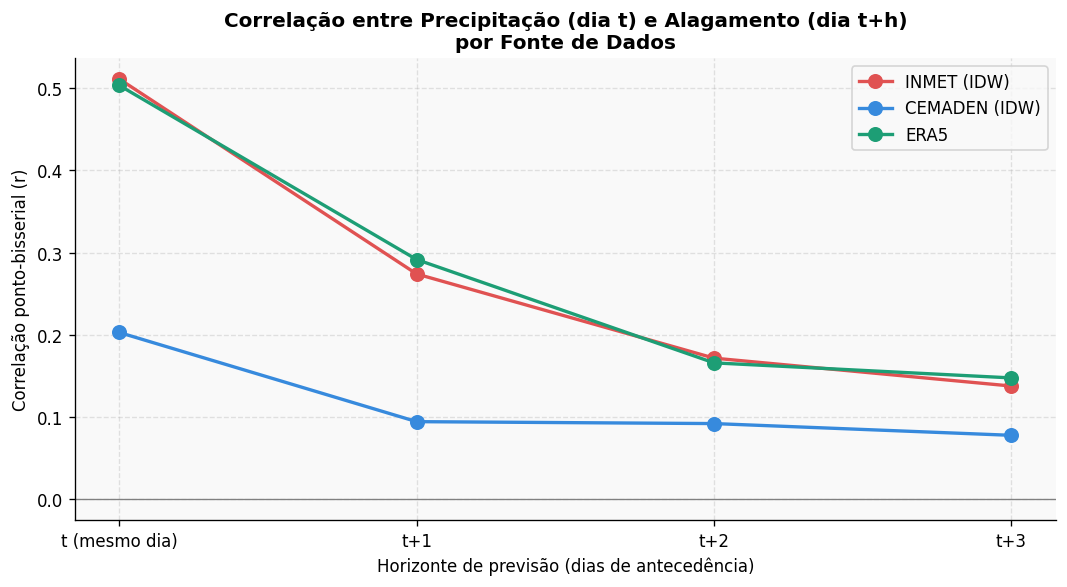


Valores plotados:
  INMET (IDW)       : h=0: r=+0.511  h=1: r=+0.274  h=2: r=+0.172  h=3: r=+0.138
  CEMADEN (IDW)     : h=0: r=+0.203  h=1: r=+0.094  h=2: r=+0.092  h=3: r=+0.078
  ERA5              : h=0: r=+0.503  h=1: r=+0.292  h=2: r=+0.166  h=3: r=+0.148


In [14]:
# ── Visualização: lag de 0 a 3 dias, comparando as fontes ──────────────────
lags_to_test = [0, 1, 2, 3]
results_lag = {"INMET (IDW)": [], "CEMADEN (IDW)": [], "ERA5": []}

for lag in lags_to_test:
    df_l = alag_daily[["date","has_flooding"]].copy().sort_values("date")
    df_l["target"] = df_l["has_flooding"].shift(-lag) if lag > 0 else df_l["has_flooding"]
    df_l = df_l.merge(inmet_diario[["date","sp_precip_mm"]], on="date", how="left")
    df_l = df_l.merge(cemaden_diario[["date","cemaden_precip_idw_mm"]], on="date", how="left")
    df_l = df_l.merge(era5[["date","precipitation_sum"]], on="date", how="left")

    for col, key in [("sp_precip_mm","INMET (IDW)"),
                     ("cemaden_precip_idw_mm","CEMADEN (IDW)"),
                     ("precipitation_sum","ERA5")]:
        sub = df_l.dropna(subset=[col,"target"])
        r, _ = stats.pointbiserialr(sub["target"], sub[col])
        results_lag[key].append(r)

fig, ax = plt.subplots(figsize=(9, 5))
for (key, vals), color in zip(results_lag.items(), [RED, BLUE, GREEN]):
    ax.plot(lags_to_test, vals, marker="o", linewidth=2, markersize=8, color=color, label=key)

ax.set_xlabel("Horizonte de previsão (dias de antecedência)")
ax.set_ylabel("Correlação ponto-bisserial (r)")
ax.set_xticks(lags_to_test)
ax.set_xticklabels(["t (mesmo dia)","t+1","t+2","t+3"])
ax.set_title("Correlação entre Precipitação (dia t) e Alagamento (dia t+h)\npor Fonte de Dados", fontweight="bold")
ax.legend()
ax.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nValores plotados:")
for key, vals in results_lag.items():
    print(f"  {key:18s}: " + "  ".join(f"h={lags_to_test[i]}: r={v:+.3f}" for i, v in enumerate(vals)))


### Leitura inicial deste resultado

Se a curva do INMET cair **mais lentamente** que a do CEMADEN ao aumentar o horizonte
(h=1, h=2, h=3), isso seria um indício a favor da hipótese de advecção: a informação de
estações distantes "duraria" mais tempo antes de perder relevância, por captar o sistema
de chuva antes de ele chegar à capital. Se as duas curvas caírem de forma parecida, a
hipótese não se sustenta nesta forma simples — o que não invalida a ideia, apenas sugere
que o sinal de advecção exigiria uma abordagem mais refinada (por exemplo, considerar a
direção do vento, ou olhar estações específicas a oeste/sudoeste separadamente das demais).

Esta é uma leitura preliminar. A formalização dessa hipótese como feature de modelo —
incluindo qual(is) estação(ões) INMET específica(s) tem maior sinal de antecedência, e em
que direção geográfica — fica para a próxima etapa de modelagem, fora do escopo exploratório
deste notebook.


## 8. Síntese desta Etapa Exploratória

### O que foi mapeado
- **96 distritos** do município de SP carregados via geojson, usados como referência espacial.
- **95 estações CEMADEN** distribuídas dentro do município — alta densidade local.
- **14 estações INMET** distribuídas pelo estado de SP, a distâncias de 24 a 239 km do
  centro da capital — densidade baixa, mas cobertura regional ampla.
- A reanálise **ERA5** fornece um ponto de grade único (~9 km de resolução) centrado em SP,
  usado como referência de comparação.

### O que foi observado
- As três fontes têm cobertura temporal distinta — CEMADEN e ERA5 cobrem o período completo
  (2015-2026) quase sem falhas, enquanto a qualidade do INMET (IDW) varia conforme a
  disponibilidade das 14 estações ao longo do tempo.
- A correlação entre as três fontes de precipitação é positiva, mas não perfeita — esperado,
  dado que medem o fenômeno em escalas espaciais diferentes (ponto local CEMADEN vs IDW
  regional INMET vs grade ERA5).
- O teste preliminar de lag (0 a 3 dias) entre cada fonte e o alagamento fornece uma primeira
  leitura sobre a hipótese de advecção, mas ainda não é conclusivo — falta repetir a análise
  estação por estação (não agregada) para isolar o efeito de cada região do estado.

### Próximos passos (modelagem, fora do escopo deste notebook)
- [ ] Extrair a série diária de cada uma das 14 estações INMET **individualmente** (não
      agregada por IDW), para testar a hipótese de advecção com granularidade espacial
- [ ] Classificar as estações por posição relativa a SP (oeste/sudoeste vs leste/litoral) e
      testar se o grupo "a favor do vento predominante" tem maior correlação com D+1
- [ ] Caso o sinal se confirme, formalizar como feature de modelo (ex: lag de precipitação
      de estações específicas) na próxima rodada de modelagem de forecasting
